In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import calendar
import os
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs(r'C:\Users\Abderrahmane\ecommerce-analysis\outputs', exist_ok=True)
print("Ready!")

Ready!


In [2]:
df = pd.read_csv('../data/Online Sales Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Year'] = df['Date'].dt.year
df = df.drop_duplicates()
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Rows: 240 | Columns: 12

Missing values:
Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
Month               0
Month_Name          0
Year                0
dtype: int64


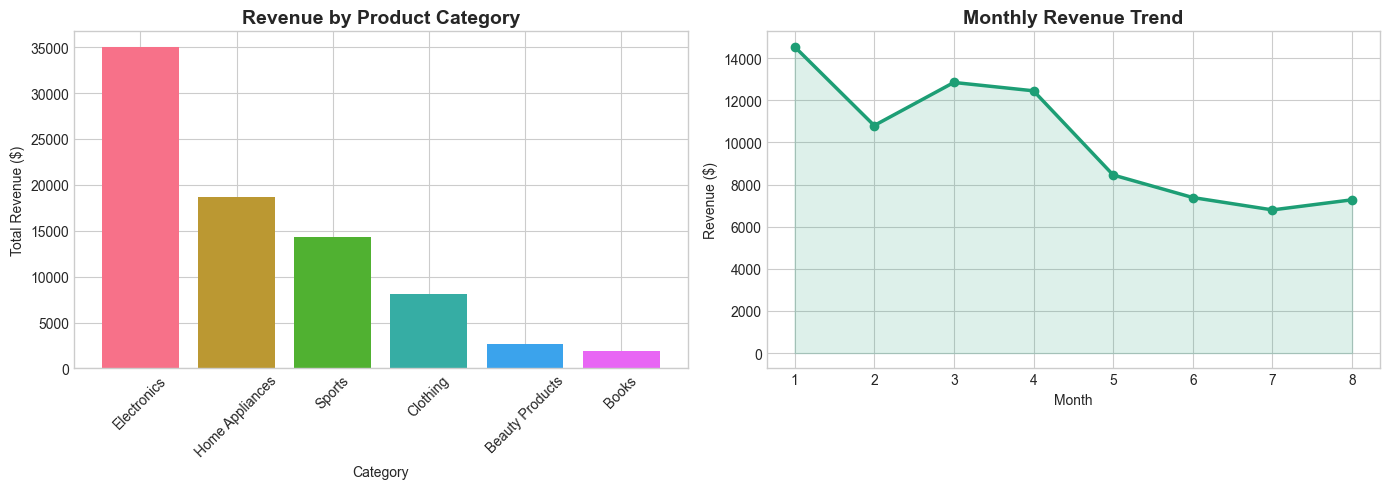

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_revenue = df.groupby('Product Category')['Total Revenue'].sum().sort_values(ascending=False)
axes[0].bar(cat_revenue.index, cat_revenue.values, color=sns.color_palette("husl", len(cat_revenue)))
axes[0].set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

monthly = df.groupby('Month')['Total Revenue'].sum()
axes[1].plot(monthly.index, monthly.values, marker='o', linewidth=2.5, markersize=6, color='#1D9E75')
axes[1].fill_between(monthly.index, monthly.values, alpha=0.15, color='#1D9E75')
axes[1].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig(r'C:\Users\Abderrahmane\ecommerce-analysis\outputs\revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

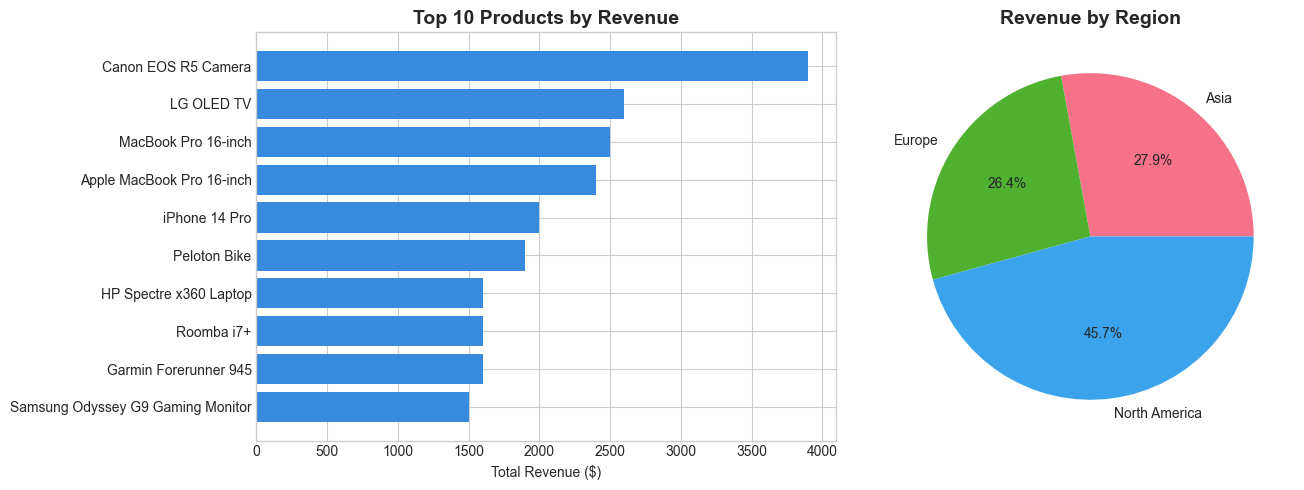

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_products = df.groupby('Product Name')['Total Revenue'].sum().nlargest(10)
axes[0].barh(top_products.index, top_products.values, color='#378ADD')
axes[0].set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].invert_yaxis()

region_data = df.groupby('Region')['Total Revenue'].sum()
axes[1].pie(region_data.values, labels=region_data.index, autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(region_data)))
axes[1].set_title('Revenue by Region', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\Abderrahmane\ecommerce-analysis\outputs\products_regions.png', dpi=150, bbox_inches='tight')
plt.show()

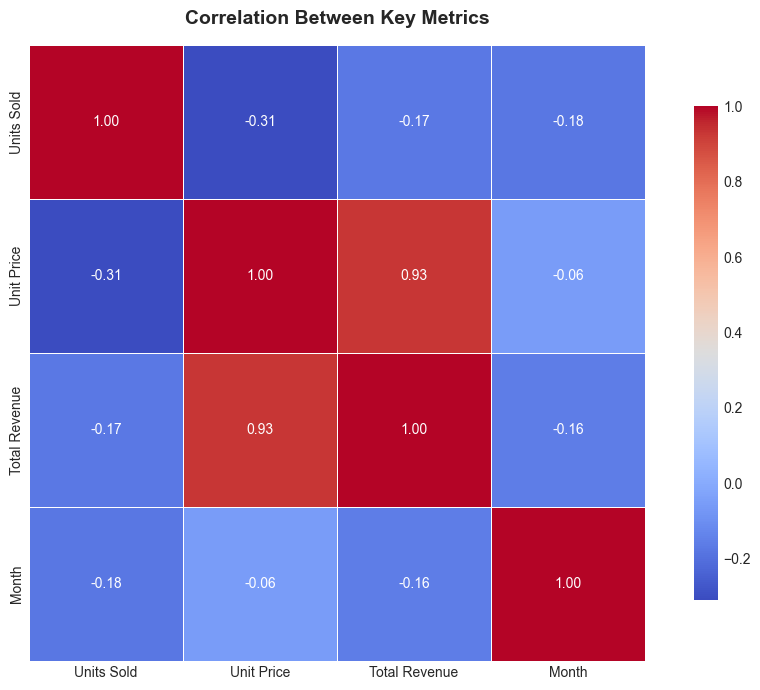

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

numeric_cols = df[['Units Sold', 'Unit Price', 'Total Revenue', 'Month']]
correlation = numeric_cols.corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Between Key Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(r'C:\Users\Abderrahmane\ecommerce-analysis\outputs\correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

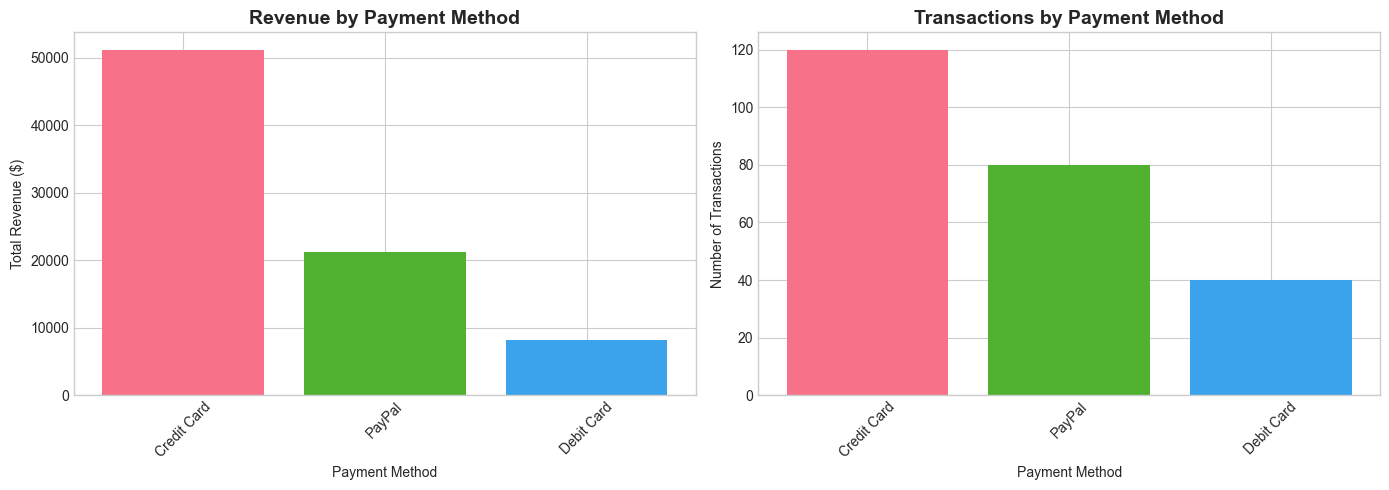

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

payment_revenue = df.groupby('Payment Method')['Total Revenue'].sum().sort_values(ascending=False)
payment_count = df.groupby('Payment Method')['Transaction ID'].count().sort_values(ascending=False)

axes[0].bar(payment_revenue.index, payment_revenue.values, color=sns.color_palette("husl", len(payment_revenue)))
axes[0].set_title('Revenue by Payment Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(payment_count.index, payment_count.values, color=sns.color_palette("husl", len(payment_count)))
axes[1].set_title('Transactions by Payment Method', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\Abderrahmane\ecommerce-analysis\outputs\payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

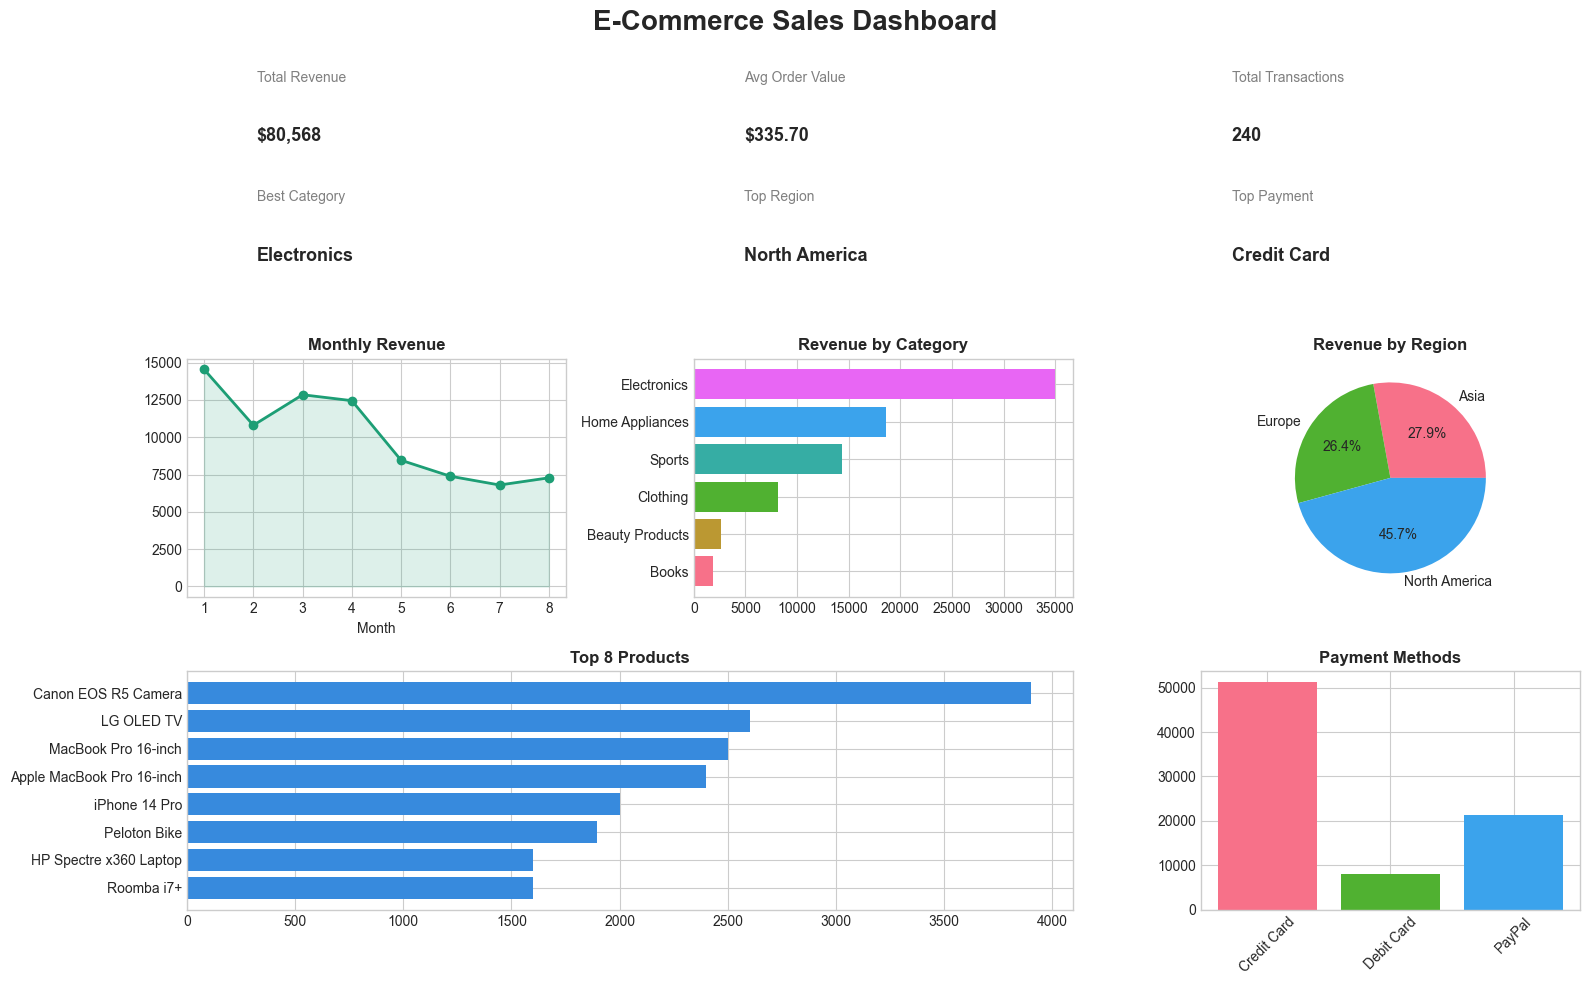

Dashboard saved!


In [7]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('E-Commerce Sales Dashboard', fontsize=20, fontweight='bold', y=0.98)

total_revenue = df['Total Revenue'].sum()
avg_order = df['Total Revenue'].mean()
total_transactions = df['Transaction ID'].nunique()
top_category = df.groupby('Product Category')['Total Revenue'].sum().idxmax()
top_region = df.groupby('Region')['Total Revenue'].sum().idxmax()
top_payment = df.groupby('Payment Method')['Total Revenue'].sum().idxmax()

# KPI Cards
ax_kpi = fig.add_subplot(3, 3, (1, 3))
ax_kpi.axis('off')
kpis = [
    ('Total Revenue', f'${total_revenue:,.0f}'),
    ('Avg Order Value', f'${avg_order:,.2f}'),
    ('Total Transactions', f'{total_transactions:,}'),
    ('Best Category', top_category),
    ('Top Region', top_region),
    ('Top Payment', top_payment),
]
for i, (label, value) in enumerate(kpis):
    x = (i % 3) * 0.35 + 0.05
    y = 0.6 if i < 3 else 0.1
    ax_kpi.text(x, y + 0.25, label, fontsize=10, color='gray', transform=ax_kpi.transAxes)
    ax_kpi.text(x, y, value, fontsize=13, fontweight='bold', transform=ax_kpi.transAxes)

# Monthly trend
ax1 = fig.add_subplot(3, 3, 4)
monthly = df.groupby('Month')['Total Revenue'].sum()
ax1.plot(monthly.index, monthly.values, marker='o', color='#1D9E75', linewidth=2)
ax1.fill_between(monthly.index, monthly.values, alpha=0.15, color='#1D9E75')
ax1.set_title('Monthly Revenue', fontweight='bold')
ax1.set_xlabel('Month')

# Category
ax2 = fig.add_subplot(3, 3, 5)
cat_rev = df.groupby('Product Category')['Total Revenue'].sum().sort_values()
ax2.barh(cat_rev.index, cat_rev.values, color=sns.color_palette("husl", len(cat_rev)))
ax2.set_title('Revenue by Category', fontweight='bold')

# Region pie
ax3 = fig.add_subplot(3, 3, 6)
region_data = df.groupby('Region')['Total Revenue'].sum()
ax3.pie(region_data.values, labels=region_data.index, autopct='%1.1f%%',
        colors=sns.color_palette("husl", len(region_data)))
ax3.set_title('Revenue by Region', fontweight='bold')

# Top products
ax4 = fig.add_subplot(3, 3, (7, 8))
top_p = df.groupby('Product Name')['Total Revenue'].sum().nlargest(8)
ax4.barh(top_p.index, top_p.values, color='#378ADD')
ax4.set_title('Top 8 Products', fontweight='bold')
ax4.invert_yaxis()

# Payment
ax5 = fig.add_subplot(3, 3, 9)
pay = df.groupby('Payment Method')['Total Revenue'].sum()
ax5.bar(pay.index, pay.values, color=sns.color_palette("husl", len(pay)))
ax5.set_title('Payment Methods', fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\Abderrahmane\ecommerce-analysis\outputs\dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [8]:
total_revenue = df['Total Revenue'].sum()
top_category = df.groupby('Product Category')['Total Revenue'].sum().idxmax()
top_month_num = df.groupby('Month')['Total Revenue'].sum().idxmax()
top_region = df.groupby('Region')['Total Revenue'].sum().idxmax()
top_payment = df.groupby('Payment Method')['Total Revenue'].sum().idxmax()
avg_order = df['Total Revenue'].mean()
top_month = calendar.month_name[top_month_num]

print("=" * 55)
print("   EXECUTIVE SUMMARY — E-COMMERCE SALES ANALYSIS")
print("=" * 55)
print(f"\n  Total Revenue:        ${total_revenue:,.0f}")
print(f"  Avg Order Value:      ${avg_order:,.2f}")
print(f"  Total Transactions:   {df['Transaction ID'].nunique():,}")
print(f"  Best Category:        {top_category}")
print(f"  Peak Month:           {top_month}")
print(f"  Top Region:           {top_region}")
print(f"  Top Payment Method:   {top_payment}")
print("\n  RECOMMENDATIONS:")
print(f"  1. Scale '{top_category}' inventory before {top_month}")
print(f"  2. Focus ad budget on {top_region} — highest ROI")
print(f"  3. Promote {top_payment} payment — most used by customers")
print(f"  4. Run discounts in low-performing months to boost revenue")
print("=" * 55)

   EXECUTIVE SUMMARY — E-COMMERCE SALES ANALYSIS

  Total Revenue:        $80,568
  Avg Order Value:      $335.70
  Total Transactions:   240
  Best Category:        Electronics
  Peak Month:           January
  Top Region:           North America
  Top Payment Method:   Credit Card

  RECOMMENDATIONS:
  1. Scale 'Electronics' inventory before January
  2. Focus ad budget on North America — highest ROI
  3. Promote Credit Card payment — most used by customers
  4. Run discounts in low-performing months to boost revenue
